# OPUS-100 Dataset Exploration

## 1  Overview

Before evaluating the machine-translation models, this notebook examines the OPUS-100 dataset. An English source sentence and its translation in a target language are provided by OPUS-100, a sizable multilingual library of parallel sentence pairs comprising 100 languages [1].

The investigation focuses on the three language pairs (en-ms, en-zh, and en-ta) because this project translates from English into Malay, Chinese, and Tamil. The goal is to comprehend the data prior to its use, including split sizes, record structure, sentence pair quality, any overlap between the test and validation splits, and sentence-length characteristics.

OPUS-100 is only used for evaluation since the project employs pre-trained translation models with no training or fine-tuning. Each language has a fixed, repeatable, and de-duplicated sample that is strictly separated from the test and validation sets. The findings are recorded for the translation-evaluation notebook, but the original dataset remains unchanged.

## 2  Importing Libraries

The investigation makes use of pandas for the tabular summaries, matplotlib for the distribution plots, pathlib for file paths, and random and a fixed seed for repeatable sampling. The OPUS-100 language-pair splits are directly loaded by the Hugging Face datasets library.

In [1]:
# Importing required libraries
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# remove all warnings
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

## 3  Loading the Dataset

Fixed validation/test sample sizes ensure that each language provides the same quantity of evaluation data, and a fixed seed makes the subsequent sampling reproducible. The original validation and test splits are loaded for each pair, and each of the three languages is mapped to its OPUS-100 configuration code and target-language key.

In [3]:
# reproducible evaluation
SEED = 42

In [4]:
# same sample sizes used in translation evaluation
VALIDATION_SIZE = 100
TEST_SIZE = 100

In [5]:
# OPUS 100 dataset
DATASET_ID = "Helsinki-NLP/opus-100"

In [6]:
# language pairs used in the project
dataset_configs = {
    "Malay": {"config": "en-ms", "target": "ms"},
    "Chinese": {"config": "en-zh", "target": "zh"},
    "Tamil": {"config": "en-ta", "target": "ta"}
}

In [7]:
# dictionaries for validation and testing datasets
validation_datasets = {}
testing_datasets = {}

In [8]:
for language, details in dataset_configs.items():
    # validaiton and testing dataset per language
    validation_datasets[language] = (load_dataset(DATASET_ID, details["config"], split="validation"))
    testing_datasets[language] = (load_dataset(DATASET_ID, details["config"], split="test"))

In [9]:
# number of records in each original split
split_results = []

In [10]:
for language in dataset_configs:
    # split results list append the records
    split_results.append({
        "Language": language,
        "Validation Records": len(validation_datasets[language]),
        "Testing Records": len(testing_datasets[language])
    })

In [11]:
# df splits dataframe
df_splits = pd.DataFrame(split_results)
df_splits

,Language,Validation Records,Testing Records
0,Malay,2000,2000
1,Chinese,2000,2000
2,Tamil,2000,2000


**Analysis:** 

For each of the three language pairings, OPUS-100 offers a standardized evaluation size of 2,000 validation and 2,000 test records. Conveniently, no language begins with more raw data than another because to this uniformity. However, as further tests show, the raw total is not the complete story because some of those 2,000 items are duplicated or overlap between divisions. There is plenty of space to draw a clean, de-duplicated sample because the 2,000 records per split are far more than the 100 that are ultimately required for evaluation. Similar to the previous datasets, the test split is held aside for the final assessment of the selected model, while the validation split is used for model selection.

## 4  Understanding the Translation Records

Each dataset's columns and a preview of the English-to-target phrase pairs are analysed to verify that the data loaded correctly and to determine which fields are being translated.

In [12]:
# dataset columns
for language in dataset_configs:
    print(language,validation_datasets[language].column_names)

Malay ['translation']
Chinese ['translation']
Tamil ['translation']


In [13]:
# first five English-reference translation pairs
for language, details in dataset_configs.items():
    # target
    target = details["target"]
    # dataset
    dataset = validation_datasets[language]
    # samples
    samples = []
    for index in range(min(5, len(dataset))):
        # translations
        translation = (dataset[index]["translation"])
        # samples append to the list and print the dataframe
        samples.append({
            "English": translation["en"],
            language: translation[target]})
    print(f"\n{language}")
    display(pd.DataFrame(samples))


Malay


,English,Malay
0,Is this why you gave up the staff surgeon posi...,Ini sebabnya kau menolak kedudukan di Hospital...
1,Ray's working.,Ray sedang bekerja.
2,Don't you know he has a phobia of fire? ! Phob...,Kamu tak tahu dia takutkan api?
3,Almost time for dinner.,Hampir masa untuk makan malam.
4,"God, why didn't you charge it?",Kenapa awak tak cas ia?



Chinese


,English,Chinese
0,"ILOAT, however, appeared to have the edge over...",然而，劳工组织行政法庭相对于联合国行政法庭似乎有些优势。
1,Tell you what. I can give you a ride to Belle'...,这样吧，我载你们到5英里外的贝拉餐厅
2,A/AC.154/363 Letter dated 20 September 2005 fr...,A/AC.154/363 2005年9月20日美利坚合众国常驻联合国代表给委员会主席的信 [...
3,"He's in jail. Maximum security, for Christ's s...",- 他人在戒备森严的牢里
4,Throughout the nineteenth century and in the f...,在整个十九世纪和二十世纪上半叶，正如我们先前听到的那样，有6 000多万欧洲人移民海外，主要...



Tamil


,English,Tamil
0,default:LTR,default:LTR
1,Minimum height set,குறைந்தபட்ச உயரத்தை அமைக்கவும்
2,You follow your religion and I follow mine.,உங்களுக்கு உங்களுடைய மார்க்கம்; எனக்கு என்னுடை...
3,Mixer cannot be found,கலப்பான் இல்லை
4,Tools,கருவிகள்


**Analysis:** 

A single translation field with the English source and its translation into the target language as a paired dictionary makes up each record. This condensed format is precisely what a translation evaluation requires the target text is used as the benchmark by which the model's output is evaluated for instance, using BLEU, and the English text is input into the model. Verifying that all three languages have the same structure allows for the extraction of the source and reference for each language without the need for special case.

## 5  Split Distribution

Before sampling, the raw balance between the three language pairs is visualized by tabulating and plotting the validation and test counts per language.

In [14]:
# validation and testing distribution
distribution = pd.DataFrame({
    "Validation": {language:len(validation_datasets[language]) for language in dataset_configs},
    "Testing": {language:len(testing_datasets[language]) for language in dataset_configs}
})

distribution

,Validation,Testing
Malay,2000,2000
Chinese,2000,2000
Tamil,2000,2000


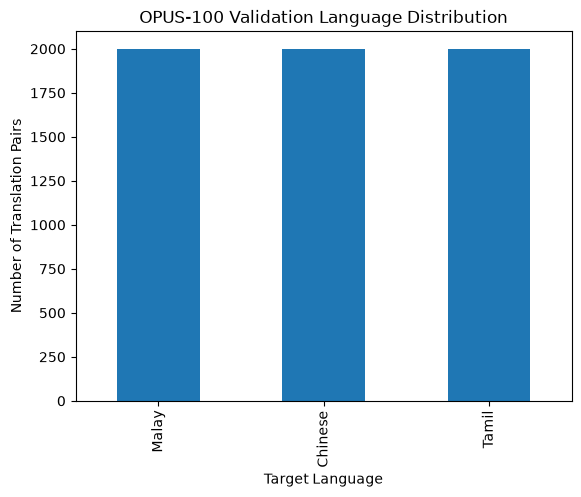

In [15]:
# validation distribution bar chart
distribution["Validation"].plot(kind="bar")
plt.title("OPUS-100 Validation Language Distribution")
plt.xlabel("Target Language")
plt.ylabel("Number of Translation Pairs")
plt.show()

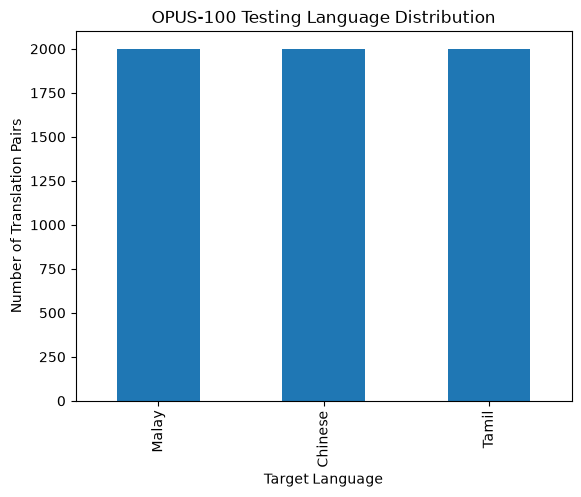

In [16]:
# testing distribution bar chart
distribution["Testing"].plot(kind="bar")
plt.title("OPUS-100 Testing Language Distribution")
plt.xlabel("Target Language")
plt.ylabel("Number of Translation Pairs")
plt.show()

**Analysis:** 

No language is overrepresented before sampling because the three language pairs are precisely balanced at the raw level, with 2,000 validation and 2,000 test each. Although this is a good place to start, it only shows the quantity of records not their quality or uniqueness. The question of whether those 2,000 records per split are indeed distinct which varies significantly between languages is examined in the sections that follow.

## 6  Checking the Translation Text

Data-quality problems, such as missing or empty English sources, missing or empty target references, duplicated English sources, and totally duplicated sentence pairs, are examined for each language and divided. These verifications verify whether the unprocessed documents are appropriate for a trustworthy translation assessment.

In [17]:
# translation data checks
checks = []

In [18]:
for language, details in dataset_configs.items():
    # target
    target = details["target"]
    for split_name, dataset in [("Validation",validation_datasets[language]),("Testing",testing_datasets[language])]:
        # the sources and references list
        sources = []
        references = []
        for record in dataset:
            # translation
            translation = record["translation"]
            # append the records to sources and references
            sources.append(translation.get("en"))
            references.append(translation.get(target))
        # series for source and reference
        source_series = pd.Series(sources,dtype="object")
        reference_series = pd.Series(references,dtype="object")
        # dataframe for source and reference
        pair_dataframe = pd.DataFrame({
            "source": source_series,
            "reference": reference_series
        })
        # append the checks for the languages
        checks.append({
            "Language": language,
            "Split": split_name,
            "Missing English": source_series.isnull().sum(),
            "Empty English": source_series.fillna("").astype(str).str.strip().eq("").sum(),
            "Missing Reference": reference_series.isnull().sum(),
            "Empty Reference": reference_series.fillna("").astype(str).str.strip().eq("").sum(),
            "Duplicated English": source_series.duplicated().sum(),
            "Duplicated Pairs": pair_dataframe.duplicated().sum()
        })

In [19]:
# dataframe for the checks
df_checks = pd.DataFrame(checks)
df_checks

,Language,Split,Missing English,Empty English,Missing Reference,Empty Reference,Duplicated English,Duplicated Pairs
0,Malay,Validation,0,0,0,0,31,17
1,Malay,Testing,0,0,0,0,25,15
2,Chinese,Validation,0,0,0,0,1,1
3,Chinese,Testing,0,0,0,0,1,0
4,Tamil,Validation,0,0,0,0,502,331
5,Tamil,Testing,0,0,0,0,497,310


**Analysis:** 

Every record is a complete sentence pair that may be translated because there are no missing or empty English sources and no missing or empty references in any language or split. The most significant conclusion here, however, is that the duplicate results vary significantly by language. The majority of the 2,000 Tamil sentences are not unique, with 502 duplicated English sources and 331 totally duplicated pairings in validation and 497 and 310 in testing, respectively. Chinese is nearly completely unique only 1 duplicated source, but Malay exhibits minor duplication around 25–31 duplicated sources per split.

This is important for a fair evaluation since, if the sample were chosen carelessly, the frequently duplicated Tamil set may evaluate the model on the same few sentences multiple times, producing an unrepresentative score. In addition to providing an early, dataset level explanation for why Tamil translation is the most challenging of the three languages in this project, this finding directly supports the de-duplication step used prior to sampling in Section 9. The available Tamil data is more repetitive and, as Section 8 demonstrates, more variable in length. The de-duplication is only applied to the sampled evaluation copy the raw files are not changed because the duplication is a feature of OPUS-100 and the dataset is only used for evaluation.

## 7  Checking Validation / Test Overlap

Here, a more severe type of contamination is examined if the same sentence pairs or English sources are included in both the test and validation splits. Overlap between the two would indicate that the model is chosen and then assessed using shared data, allowing selection-related information to seep into the outcome.

In [20]:
# check exact source and translation pair overlap
overlap_results = []

In [21]:
for language, details in dataset_configs.items():
    # target
    target = details["target"]
    # validation and testing pairs
    validation_pairs = {(str(record["translation"]["en"]).strip(), str(record["translation"][target]).strip()) for record in validation_datasets[language]}
    testing_pairs = {(str(record["translation"]["en"]).strip(), str(record["translation"][target]).strip()) for record in testing_datasets[language]}
    # validaiton and testing sources
    validation_sources = {pair[0] for pair in validation_pairs}
    testing_sources = {pair[0] for pair in testing_pairs}
    # overlap results append to the list
    overlap_results.append({
        "Language": language,
        "Exact Pair Overlap": len(validation_pairs & testing_pairs),
        "English Source Overlap": len(validation_sources & testing_sources)
    })

In [22]:
# df overlap dataframe
df_overlap = pd.DataFrame(overlap_results)
df_overlap

,Language,Exact Pair Overlap,English Source Overlap
0,Malay,17,27
1,Chinese,0,1
2,Tamil,307,349


**Analysis:** 

The overlap shows that raw OPUS-100 cannot be used as it is and varies significantly by language. Tamil is severely impacted 349 English sources and 307 precise sentence pairs present in both the validation and test splits, which would significantly skew any evaluation that used the raw splits directly because sentences selected during model selection would recur in the final test. Chinese is practically clean (0 pairs, 1 source), but Malay has some overlap (17 pairs, 27 sources).

This is the most convincing explanation for the careful sampling approach in Section 9, which explicitly excludes from the test pool any English source already picked for validation in addition to de-duplicating inside each split. A important methodological safeguard is identifying and removing this leakage without it, the translation findings, especially for Tamil, would be optimistically biased and untrustworthy.

## 8  Checking Text Lengths

Both the overall and language-specific character and word lengths of the source and reference sentences are analysed. Sentence length influences the complexity of translation and helps in describing the degree of similarity between the three language pairs.

In [23]:
# text length properties
length_records = []

In [24]:
for language, details in dataset_configs.items():
    # target
    target = details["target"]
    for split_name, dataset in [("Validation",validation_datasets[language]),("Testing",testing_datasets[language])]:
        for record in dataset:
            # translation, source, reference
            translation = (record["translation"])
            source = str(translation["en"])
            reference = str(translation[target])
            # length records append to the list
            length_records.append({
                "Language": language,
                "Split": split_name,
                "Source Characters": len(source),
                "Reference Characters": len(reference),
                "Source Words": len(source.split())
            })

In [25]:
# dataframe for df_lenghts
df_lengths = pd.DataFrame(length_records)
df_lengths.head()

,Language,Split,Source Characters,Reference Characters,Source Words
0,Malay,Validation,71,66,13
1,Malay,Validation,14,19,2
2,Malay,Validation,57,31,13
3,Malay,Validation,23,30,4
4,Malay,Validation,30,23,6


In [26]:
# English source character lengths
df_lengths["Source Characters"].describe().to_frame()

,Source Characters
count,12000.000000
mean,71.126750
std,98.484443
min,1.000000
25%,19.000000
50%,36.000000
75%,79.000000
max,2236.000000


In [27]:
# target reference character lengths
df_lengths["Reference Characters"].describe().to_frame()

,Reference Characters
count,12000.000000
mean,43.951417
std,59.561257
min,1.000000
25%,16.000000
50%,30.000000
75%,51.000000
max,2058.000000


In [28]:
# lengths for each language
df_lengths.groupby("Language")[["Source Characters", "Reference Characters"]].describe()

Source Characters                                                  \
                     count       mean         std  min   25%    50%    75%   
Language                                                                     
Chinese             4000.0  136.81300  131.943423  4.0  44.0  104.0  192.0   
Malay               4000.0   39.28650   31.246736  3.0  21.0   32.0   48.0   
Tamil               4000.0   37.28075   65.125466  1.0   9.0   18.0   37.0   

                 Reference Characters                                        \
             max                count      mean        std  min   25%   50%   
Language                                                                      
Chinese   2236.0               4000.0  40.62200  39.868860  2.0  14.0  31.0   
Malay      744.0               4000.0  42.64075  39.297071  3.0  22.0  33.0   
Tamil     1586.0               4000.0  48.59150  86.465465  1.0  12.0  24.0   

                        
           75%     max  
Language                
Chinese   55.0   858.0  
Malay     51.0   782.0  
Tamil     44.0  2058.0

**Analysis:** 

The average length of the English sources is 71 characters (median 36) across all records, while the average length of the references is 44 characters (median 30). However, the distribution is quite large the longest English source is 2,236 characters, suggesting that there are many short sentences in addition to a few very long ones. The most instructive section is the breakdown by language Chinese sources are by far the longest (mean 137 characters), indicating the difference writing system and information density, but Tamil (37) and Malay (39) sources are significantly shorter on average. With a maximum reference length of 2,058 characters and a source standard deviation of 65, Tamil shows significantly more variability than Malay.

These differences matter when interpreting the later BLEU results the three language pairs are not equally difficult, and Tamil's combination of high duplication (Section 6), cross-split overlap (Section 7) and high length variability makes it the most challenging and least clean of the three. Any poorer Tamil translation performance in the evaluation chapter can be explained by this dataset-level evidence.

## 9  Preparing the Evaluation Splits

For every language, clean, repeatable validation and test samples are produced. To ensure that the two evaluation sets are completely independent, each split is transformed into a table, missing, empty, and duplicate pairings are removed, a fixed-seed sample is drawn, and any English source used in validation is removed from the test pool prior to the test sample being generated.

In [29]:
# clean and reproducible validation/test samples
validation_data = {}
testing_data = {}

In [30]:
for language, details in dataset_configs.items():
    target = details["target"]
    # convert complete validation split to DataFrame
    validation_df = pd.DataFrame({
        "source": [record["translation"]["en"] for record in validation_datasets[language]],
        "reference": [ record["translation"][target] for record in validation_datasets[language]]
    })

    # convert complete test split to DataFrame
    testing_df = pd.DataFrame({
        "source": [record["translation"]["en"] for record in testing_datasets[language]],
        "reference": [record["translation"][target] for record in testing_datasets[language]]
    })

    # remove missing, empty and duplicate pairs
    validation_df = (validation_df.dropna(subset=["source", "reference"]).drop_duplicates(subset=["source", "reference"]))
    testing_df = (testing_df.dropna(subset=["source", "reference"]).drop_duplicates(subset=["source", "reference"]))
    validation_df = validation_df[validation_df["source"].str.strip().ne("") & validation_df["reference"].str.strip().ne("")]
    testing_df = testing_df[testing_df["source"].str.strip().ne("") & testing_df["reference"].str.strip().ne("")]
    # reproducible validation sample
    validation_sample = validation_df.sample(n=VALIDATION_SIZE, random_state=SEED).reset_index(drop=True)
    # prevent the same English source appearing in test
    validation_sources = set(validation_sample["source"])
    testing_pool = testing_df[~testing_df["source"].isin(validation_sources)]
    # reproducible held out test sample
    testing_sample = testing_pool.sample(n=TEST_SIZE, random_state=SEED + 1).reset_index(drop=True)
    validation_data[language] = validation_sample
    testing_data[language] = testing_sample

In [31]:
# verify that evaluation samples are independent
for language in dataset_configs:
    # validation and testing pairs
    validation_pairs = set(map(tuple,validation_data[language][["source", "reference"]].to_numpy()))
    testing_pairs = set(map(tuple,testing_data[language][["source", "reference"]].to_numpy()))
    # validation and testing sources
    validation_sources = set(validation_data[language]["source"])
    testing_sources = set(testing_data[language]["source"])
    # assert testings
    assert validation_pairs.isdisjoint(testing_pairs)
    assert validation_sources.isdisjoint(testing_sources)
    assert not validation_data[language].duplicated(subset=["source", "reference"]).any()
    assert not testing_data[language].duplicated(subset=["source", "reference"]).any()

In [32]:
# evaluation counts
evaluation_counts = []

In [33]:
for language in dataset_configs:
    # evaluation counts append to the list
    evaluation_counts.append({
        "Language": language,
        "Validation Records":len(validation_data[language]),
        "Testing Records":len(testing_data[language])
    })

In [34]:
# df evaluation dataframe
df_evaluation = pd.DataFrame(evaluation_counts)
df_evaluation

,Language,Validation Records,Testing Records
0,Malay,100,100
1,Chinese,100,100
2,Tamil,100,100


**Analysis:** 

Each language produces precisely 100 validation and 100 testing records following cleaning and sampling, resulting in a perfectly balanced assessment set of 600 sentence pairs overall. An essential component of this is the assertion block, which programmatically verifies that the test and validation pairs are disjoint, that their English sources are disjoint, that neither sample contains duplicates. This creates a guaranteed clean evaluation set from the preceding findings (high Tamil duplication and overlap) the source-exclusion phase removes the cross-split leakage found in Section 7, and the de-duplication method removes repeated sentences. The entire selection is reproducible because fixed seeds are used throughout.

## 10  Verifying the Selected Evaluation Data

In order to ensure that the cleaning in Section 9 was successful, the chosen samples are double checked for any missing, empty, or duplicate entries as well as for any overlap between the validation and test sets.

In [35]:
# selected evaluation records
selected_checks = []

In [36]:
for language in dataset_configs:
    for split_name, dataset in [("Validation", validation_data[ language]), ("Testing",testing_data[ language])]:
        # selected checks append to the list
        selected_checks.append({
            "Language": language,
            "Split": split_name,
            "Missing Source": dataset["source"].isnull().sum(),
            "Empty Source": dataset["source"].fillna("").str.strip().eq("").sum(),
            "Missing Reference":dataset["reference"].isnull().sum(),
            "Empty Reference": dataset["reference"].fillna("").str.strip().eq("").sum(),
            "Duplicated Pairs": dataset.duplicated().sum()
        })

In [37]:
# dataframe for selected checks
pd.DataFrame(selected_checks)

,Language,Split,Missing Source,Empty Source,Missing Reference,Empty Reference,Duplicated Pairs
0,Malay,Validation,0,0,0,0,0
1,Malay,Testing,0,0,0,0,0
2,Chinese,Validation,0,0,0,0,0
3,Chinese,Testing,0,0,0,0,0
4,Tamil,Validation,0,0,0,0,0
5,Tamil,Testing,0,0,0,0,0


In [38]:
# check whether selected validation/test samples overlap
selected_overlap = []

In [39]:
for language in dataset_configs:
    # validaiton and testing pairs
    validation_pairs = set(map(tuple,validation_data[language][["source", "reference"]].to_numpy()))
    testing_pairs = set(map(tuple, testing_data[language][["source","reference"]].to_numpy()))
    # selected overlap append the details
    selected_overlap.append({
        "Language": language,
        "Selected Pair Overlap":len(validation_pairs & testing_pairs)
    })

In [40]:
# dataframe for selected overlap
pd.DataFrame(selected_overlap)

,Language,Selected Pair Overlap
0,Malay,0
1,Chinese,0
2,Tamil,0


**Analysis:** 

The re-checks confirm the evaluation data is completely clean zero missing sources, zero empty sources, zero missing or empty references and zero duplicated pairs across every language and split, and zero selected-pair overlap between validation and test for all three languages. Because Tamil in particular began with such significant duplication and overlap, this independent verification after sampling is purposefully thorough. Showing that the final samples are demonstrably clean gives confidence that the subsequent translation results are reliable and not distorted by repeated or leaked sentences.

## 11  Saving the Evaluation Data

In order for the translation-evaluation notebook to load the cleaned validation and test samples directly and verify their presence, they are written to per-language CSV files in distinct validation and testing folders.

In [41]:
# processed data folders
processed_folder = Path("../../data/processed/opus100_translation")
validation_folder = (processed_folder / "validation")
testing_folder = (processed_folder / "testing")
validation_folder.mkdir(parents=True, exist_ok=True)
testing_folder.mkdir(parents=True,exist_ok=True)

In [42]:
# save each target language separately
for language in dataset_configs:
    filename = (language.lower() + ".csv")
    validation_data[language].to_csv(validation_folder / filename, index=False)
    testing_data[language].to_csv(testing_folder / filename, index=False)

In [43]:
# confirm files were saved
for language in dataset_configs:
    filename = (language.lower() + ".csv")
    print(language, "validation:",(validation_folder / filename).exists(), "| testing:",( testing_folder / filename).exists())

Malay validation: True | testing: True
Chinese validation: True | testing: True
Tamil validation: True | testing: True


**Analysis:** 

All six files (Malay, Chinese, and Tamil validation and testing) were successfully saved. Storing the cleaned samples means the careful de-duplication and leakage-removal performed in this notebook is done once and reused by the evaluation, rather than risking the raw, contaminated splits being loaded by mistake. The original OPUS-100 data is preserved, and the model-selection and final-evaluation data are kept distinctly apart by the division into validation and testing files.

## 12  Conclusion

The OPUS-100 dataset was examined for the project's three target languages Tamil, Chinese, and Malay. The quality checks showed significant issues concentrated in Tamil heavy duplication more than 300 fully duplicated pairs per split and serious validation/test overlap (307 shared pairs), with Malay slightly impacted and Chinese nearly clean, despite the fact that all three started with the same raw size of 2,000 validation and 2,000 test records with complete, non-empty sentence pairs.

These results influenced a methodical approach to preparation. A fixed-seed sample of 100 validation and 100 testing pairings per language was selected and programmatically confirmed to be independent and free of duplicates. The data for each language was de-duplicated, and any English source that appeared in validation was excluded from the test pool. The length analysis also revealed that the three pairs are not equally challenging, with Tamil being the most variable relevant context for comprehending the translation results and Chinese sources being significantly longer. The original OPUS-100 files remained unchanged, but the cleaned, balanced, and leak-free samples were saved for the evaluation phase.

## References

[1] B. Zhang, P. Williams, I. Titov, and R. Sennrich, "Improving massively multilingual neural machine translation and zero-shot translation," in Proc. 58th Annu. Meeting Assoc. Comput. Linguistics (ACL), 2020, pp. 1628-1639. [Online]. Available: https://doi.org/10.18653/v1/2020.acl-main.148. [Accessed: 27 June 2026].